# Mini Project: Predicting Cancer Severity

## Project Description

In this project, you will explore a real-world dataset of **global cancer patients from 2015 to 2024**. The goal is to build a predictive model that estimates the **Target Severity Score** of a patient's cancer based on various features like demographics, environmental exposures, cancer type/stage, and lifestyle factors.

---

## Dataset Overview

- **Rows**: 50,000 patient records  
- **Columns**: 15 features  
- **Target Variable**: `Target_Severity_Score`  
- **Key Features**:
  - `Age`, `Gender`, `Country_Region`, `Year`
  - `Genetic_Risk`, `Air_Pollution`, `Alcohol_Use`, `Smoking`, `Obesity_Level`
  - `Cancer_Type`, `Cancer_Stage`, `Treatment_Cost_USD`, `Survival_Years`

---

## Objectives

1. Understand and preprocess the dataset.
2. Explore and visualize important patterns.
3. Build machine learning models to predict `Target_Severity_Score`.
4. Evaluate and compare model performances.
5. Draw key insights and recommendations.

---

## Project Steps

### 1. Data Preprocessing
- Handle missing values (if any)
- Encode categorical variables
- Normalize/scale features
- Train-test split

### 2. Exploratory Data Analysis (EDA)
- Visualize distributions and correlations
- Compare cancer severity across types/stages/regions

### 3. Modeling
- Train regression models:
  - Linear Regression
  - DecisionTreeRegressor

### 4. Evaluation
- Use metrics such as:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - R² Score

### 5. Visualization & Conclusions
- Visualize predictions vs actual values
- Feature importance analysis
- Conclude findings and potential use cases

---

## Required Packages

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


* **INSTALLING THE SCIKIT LIBRARY**  

In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**1.** **Importing Essential Libraries for Machine Learning Regression**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

**2. Loading and Inspecting a Global Cancer Patient Dataset**

In [3]:
df=pd.read_csv('global_cancer_patients_2015_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

**3. Checking Unique Values in Categorical Columns**

In [4]:
for c in df.columns:
    if df[c].dtype=='object':
        print(df[c].unique())

['PT0000000' 'PT0000001' 'PT0000002' ... 'PT0049997' 'PT0049998'
 'PT0049999']
['Male' 'Female' 'Other']
['UK' 'China' 'Pakistan' 'Brazil' 'Germany' 'Canada' 'USA' 'India'
 'Australia' 'Russia']
['Lung' 'Leukemia' 'Breast' 'Colon' 'Skin' 'Cervical' 'Prostate' 'Liver']
['Stage III' 'Stage 0' 'Stage II' 'Stage I' 'Stage IV']


**4. Generating Descriptive Statistics for Numerical Data**

In [5]:
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


**5. Checking for Missing Values in the Dataset**

In [6]:
df.isnull().sum()


Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

**NO MISSING VALUES**

**5.COPY DATA SET**

In [7]:

df1 = df.copy()

**6. Encode Categorical Feature**

In [8]:


cat_cols = ["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    encoders[c] = le

**6.1.CHECK THE ENCODING STATUS**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  int64  
 3   Country_Region         50000 non-null  int64  
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  int64  
 11  Cancer_Stage           50000 non-null  int64  
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

**6.2 CHECK THE FIRST VALUES AFTER ENCODING**

In [10]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,1,8,2021,6.4,2.8,9.5,0.9,8.7,5,3,62913.44,5.9,4.92
1,PT0000001,34,1,3,2021,1.3,4.5,3.7,3.9,6.3,3,0,12573.41,4.7,4.65
2,PT0000002,80,1,6,2023,7.4,7.9,2.4,4.7,0.1,0,2,6984.33,7.1,5.84
3,PT0000003,40,1,8,2015,1.7,2.9,4.8,3.5,2.7,2,1,67446.25,1.6,3.12
4,PT0000004,43,0,1,2017,5.1,2.8,2.3,6.7,0.5,7,3,77977.12,2.9,3.62


# Machine Learning Preprocessing Pipeline: From Raw Data to Scaled Splits
## 1. Preparing Features and Target Variable
###### **LINES 1 AND 2**
## 2.Splitting Data into Train/Test Sets
###### **LINE 3**
## 3. Initializing Feature Scaler
###### **LINE 4**
## 4. Scaling Training Data
###### **LINE 5**
## 5. Scaling Test Data
###### **LINE 6**

In [11]:

X = df.drop(columns=["Target_Severity_Score","Patient_ID"])
y = df["Target_Severity_Score"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=86)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

## 6.DISTRIBUTION DESCRIPTION GRAPHS

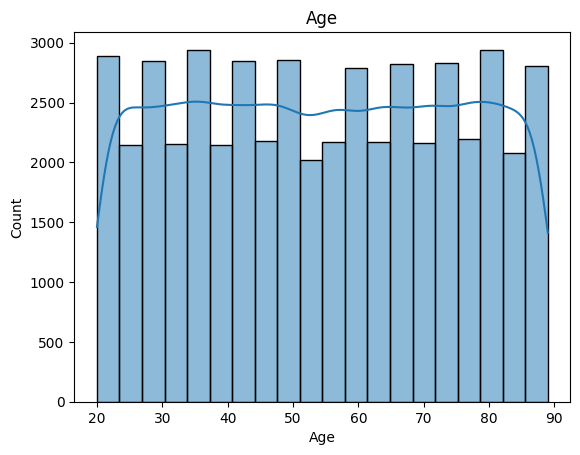

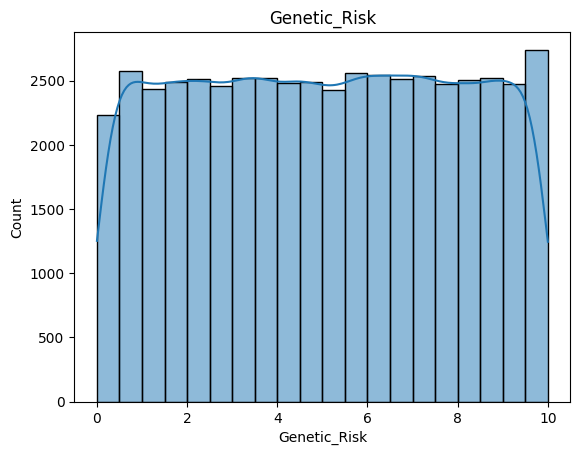

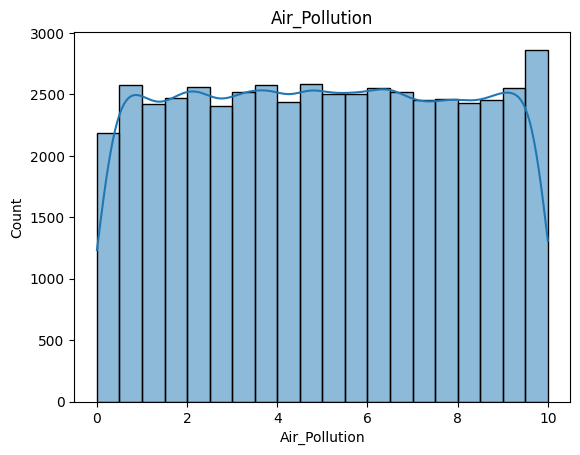

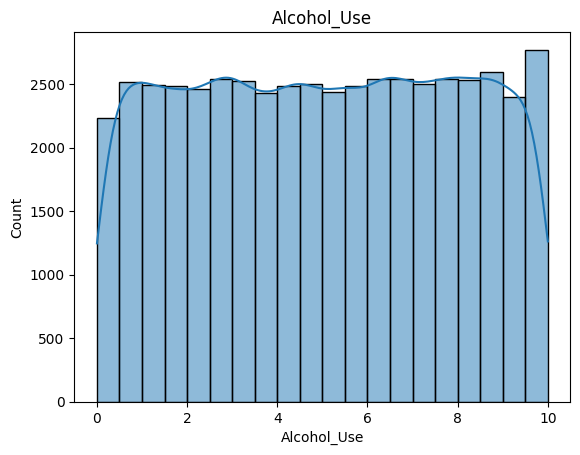

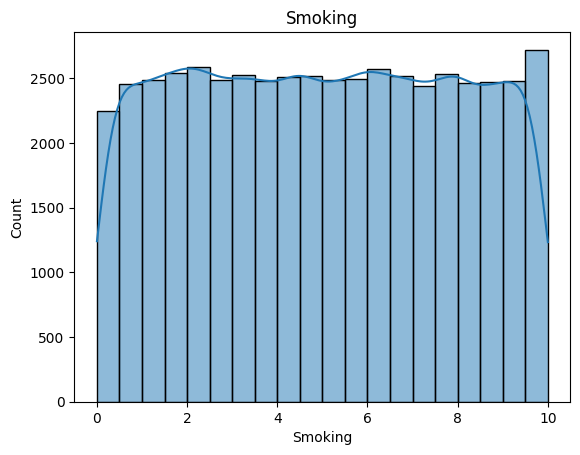

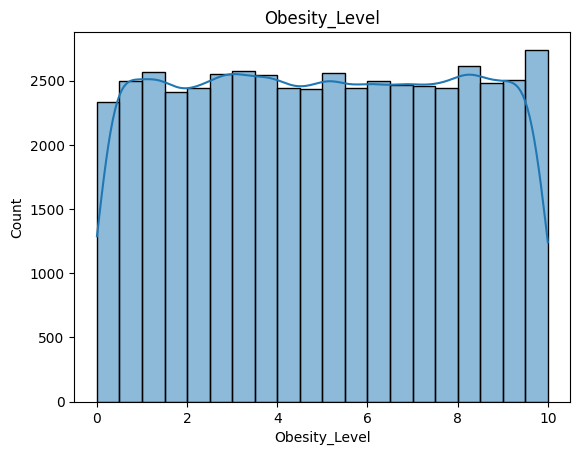

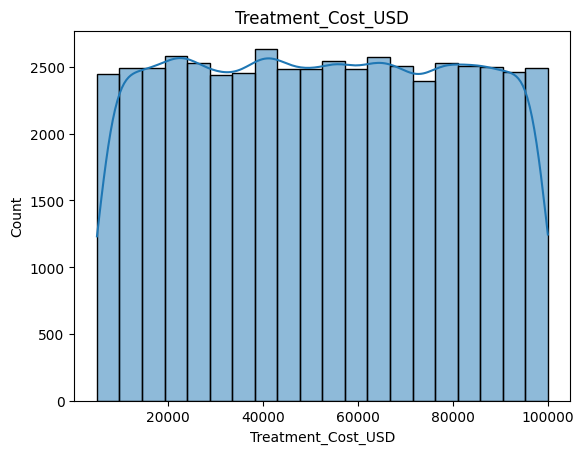

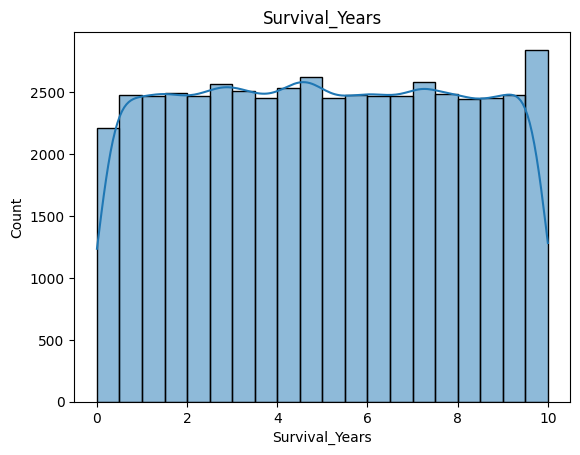

In [12]:


num_cols = ["Age","Genetic_Risk","Air_Pollution","Alcohol_Use",
            "Smoking","Obesity_Level","Treatment_Cost_USD","Survival_Years"]
for c in num_cols:
    sns.histplot(df[c], bins=20, kde=True); plt.title(c); plt.show()

## **7.Matrice de Corrélation : Exploration des Relations entre Variables Médicales**

In [13]:
corr_matrix = df.drop(columns=["Patient_ID"]).corr(numeric_only=True)


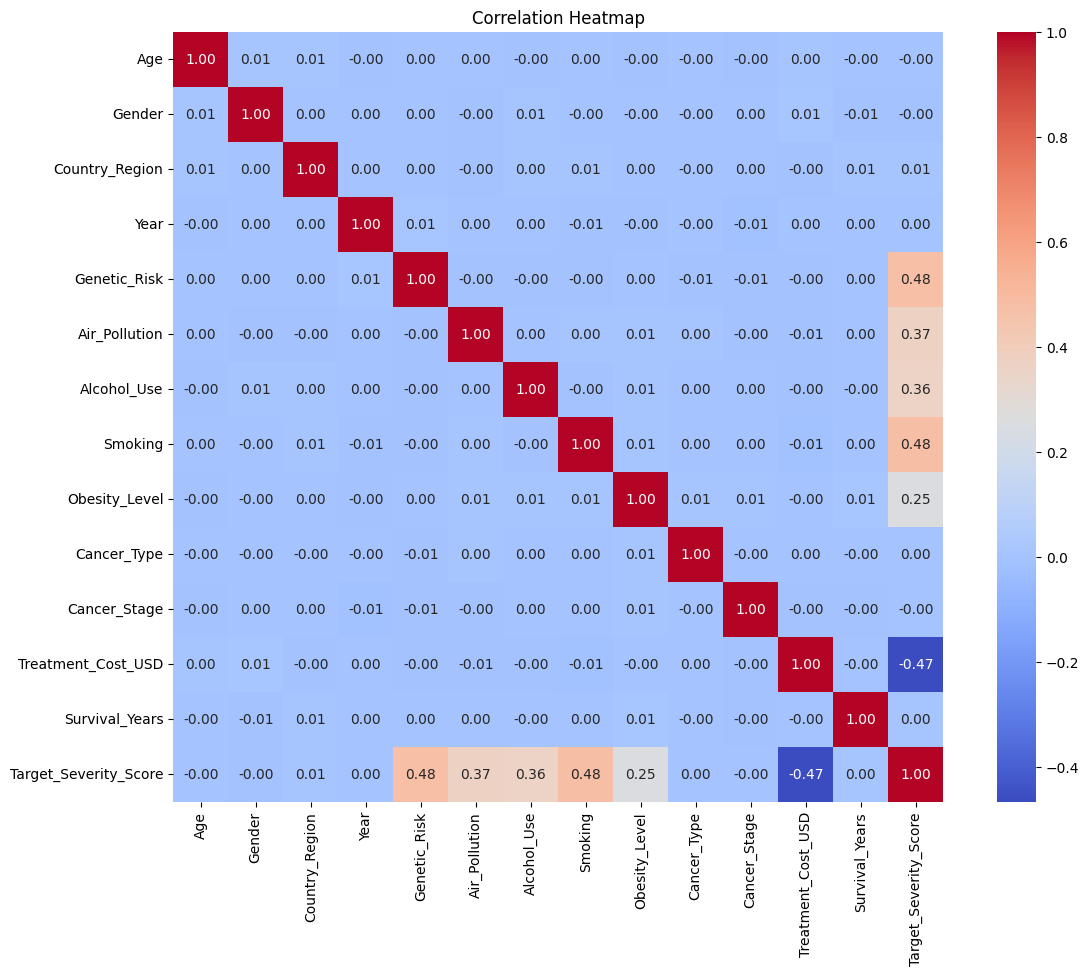

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()


**NOTE :high correlation with Target_Severity_Score: Genetic_Risk, Air_Pollution, Alcohol_Use, Smoking, Obesity_Level and Treatment_Cost_USD**

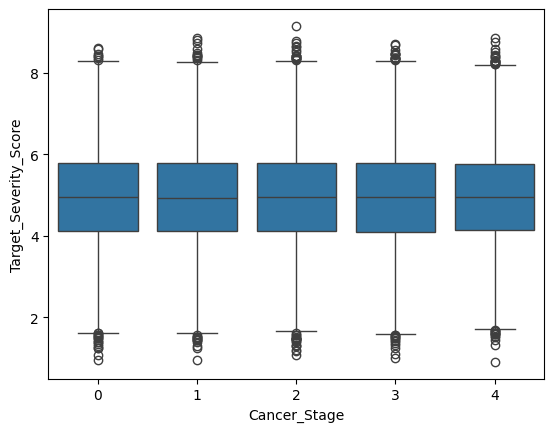

In [15]:

sns.boxplot(data=df, x="Cancer_Stage", y="Target_Severity_Score"); plt.show()

## 8.Plot severity by cancer type, stage, and region
### **8.1. Cancer Type**
**line 2 to 5**
### **8.2. Cancer Stage**
**line 6 to 8**
### **8.3. Top 10 Countries**
**line 9 to 11**

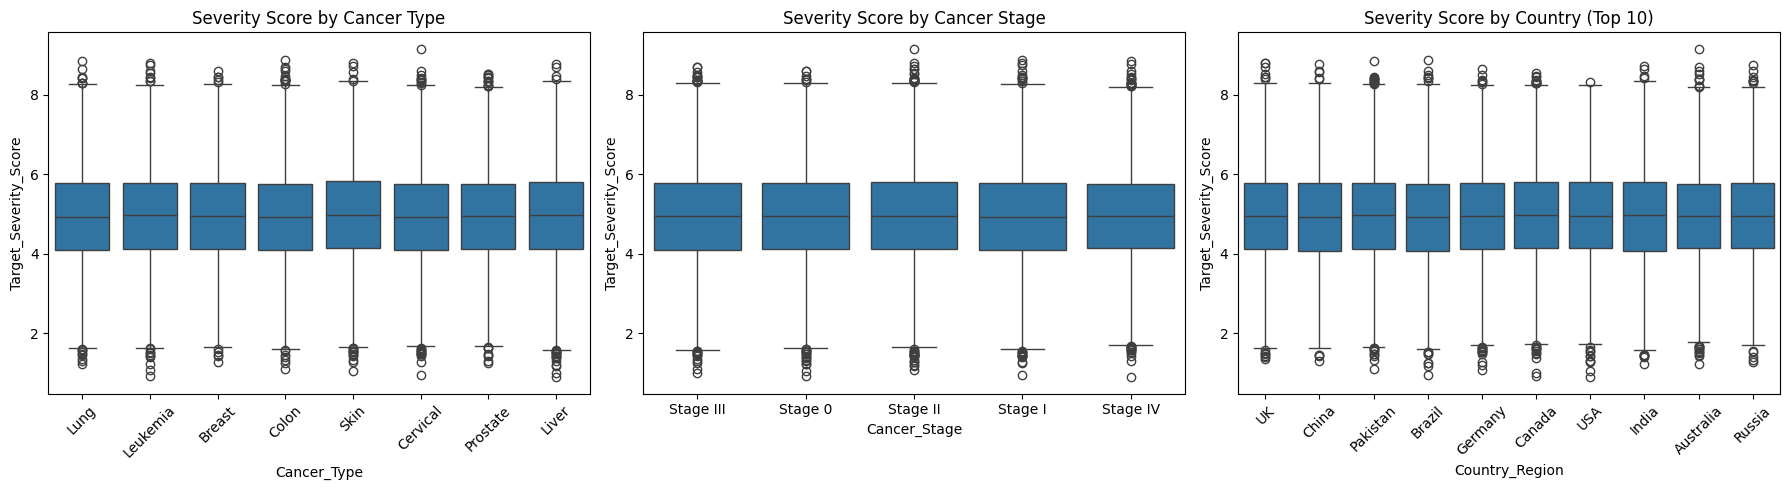

In [16]:




plt.figure(figsize=(18, 5))

 
plt.subplot(1, 3, 1)
sns.boxplot(data=df1, x='Cancer_Type', y='Target_Severity_Score')
plt.xticks(rotation=45)
plt.title("Severity Score by Cancer Type")


plt.subplot(1, 3, 2)
sns.boxplot(data=df1, x='Cancer_Stage', y='Target_Severity_Score')
plt.title("Severity Score by Cancer Stage")


top_countries = df1['Country_Region'].value_counts().nlargest(10).index
plt.subplot(1, 3, 3)
sns.boxplot(data=df1[df1['Country_Region'].isin(top_countries)],
            x='Country_Region', y='Target_Severity_Score')
plt.xticks(rotation=45)
plt.title("Severity Score by Country (Top 10)")

plt.tight_layout()
plt.show()


### Analyse des Scores de Sévérité (Boxplots)

Les trois boxplots comparent les **Topic-Specific Severity Scores** selon :
- le **type de cancer**,
- le **stade du cancer**,
- et le **pays/région**.

#### Observations :
- Les **médianes** sont proches (~4.0) dans tous les cas.
- Peu de **variation** entre les groupes, quelle que soit la catégorie.
- Présence d’**outliers**, mais sans tendance marquée.
- Les scores semblent **homogènes**, suggérant une **perception uniforme** de la sévérité.

#### Conclusion :
La sévérité perçue varie peu selon le type, le stade ou la localisation du cancer. Cela peut refléter une **standardisation des scores** ou une **perception biaisée** dans l’ensemble des données.


## 9.Régression 
### 9.1.Régression linéaire 

In [17]:


lr = LinearRegression().fit(X_tr_s, y_tr)
y_pred_lr = lr.predict(X_te_s)
print("LinearRegression: MAE", mean_absolute_error(y_te,y_pred_lr), 'RMSE',
             root_mean_squared_error(y_te,y_pred_lr), 'R2',
             r2_score(y_te,y_pred_lr))

LinearRegression: MAE 0.0025003437295351917 RMSE 0.002890033749213138 R2 0.9999941422698192


### 9.2.Régresssion par arbre de décision 

In [18]:

dt = DecisionTreeRegressor(random_state=86).fit(X_tr_s,y_tr)
y_pred_dt = dt.predict(X_te_s)
print("DecisionTree: MAE", mean_absolute_error(y_te,y_pred_dt), 'RMSE',
             root_mean_squared_error(y_te,y_pred_dt), 'R2',
             r2_score(y_te,y_pred_dt))

DecisionTree: MAE 0.291922 RMSE 0.3687652369733351 R2 0.904627430730353


### Résultats des Modèles de Régression

| Modèle              | MAE        | RMSE       | R²        |
|---------------------|------------|------------|-----------|
| Régression Linéaire | 0.00250    | 0.00289    | 0.99999   |
| Arbre de Décision   | 0.28915    | 0.36435    | 0.90657   |

#### Analyse rapide :
- La **régression linéaire** donne des résultats **quasi-parfaits**.
- L’**arbre de décision** est moins précis, avec des erreurs plus élevées.
- La relation semble **fortement linéaire**, donc la régression linéaire est le **meilleur choix** ici.


### 9.3.Comparaison entre les deux modeles 

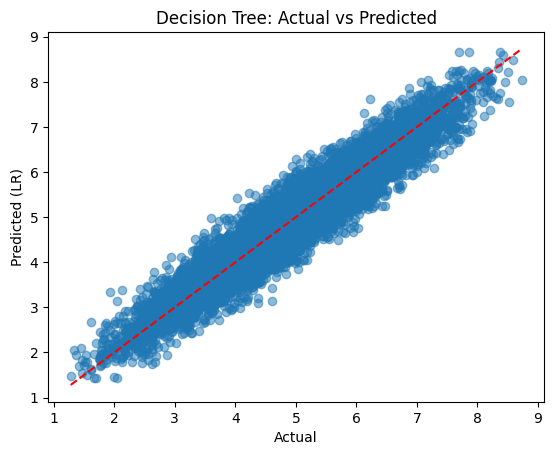

In [19]:


plt.scatter(y_te, y_pred_dt, alpha=.5)
plt.plot([y_te.min(),y_te.max()],[y_te.min(),y_te.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted (LR)")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

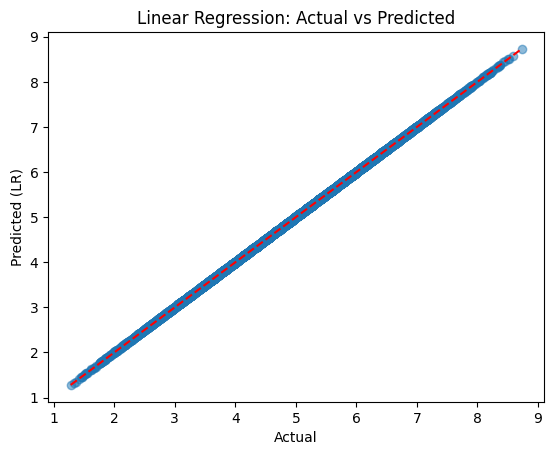

In [20]:
plt.scatter(y_te, y_pred_lr, alpha=.5)
plt.plot([y_te.min(),y_te.max()],[y_te.min(),y_te.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted (LR)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

### Comparaison entre Prédictions et Réel

#### Régression Linéaire :

- Les points sont presque parfaitement alignés sur la ligne rouge.
- L’écart entre les valeurs prédites et réelles est extrêmement faible.

#### Arbre de Décision :

- Les points sont globalement plus dispersés autour de la diagonale.
- Les écarts sont plus marqués, notamment aux extrêmes.


### 9.4.Visualizing Feature Importance in a Decision Tree Model

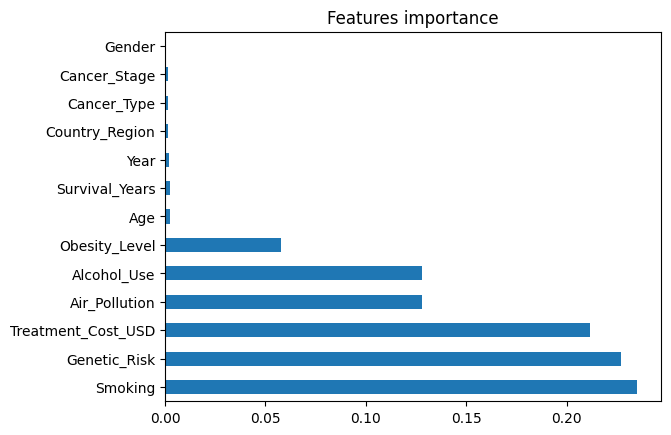

In [21]:
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot.barh()
plt.title("Features importance")
plt.show()

# Interprétation du graphique "Features Importance"

Ce graphique présente l'influence relative de chaque variable dans un modèle de type arbre de décision, probablement utilisé pour prédire un résultat lié au cancer.

## Variables les plus influentes

1. **Smoking (~23%)** : Le tabagisme est la variable la plus déterminante, ce qui reflète bien son lien connu avec les cancers.
2. **Genetic_Risk (~22%)** : Le risque génétique joue un rôle presque équivalent, soulignant l'importance des antécédents familiaux.
3. **Treatment_Cost_USD (~20%)** : Le coût du traitement peut indiquer indirectement la gravité de la maladie ou l'accès aux soins.
4. **Alcohol_Use (~13%)** : L'usage d’alcool est aussi un facteur non négligeable.
5. **Air_Pollution (~12%)** : La pollution de l’air influence également les prédictions.
6. **Obesity_Level (~5%)** : L’obésité a un impact modéré mais présent.

## Variables peu influentes

- Survival_Years  
- Age  
- Country_Region  
- Year  
- Cancer_Type  
- Cancer_Stage  
- Gender  

Ces variables ont une importance proche de zéro. Elles n'apportent probablement pas d'information utile au modèle ou sont redondantes par rapport à d'autres.




### 9.4 Visualizing the Most Influential Coefficients in Linear Regression

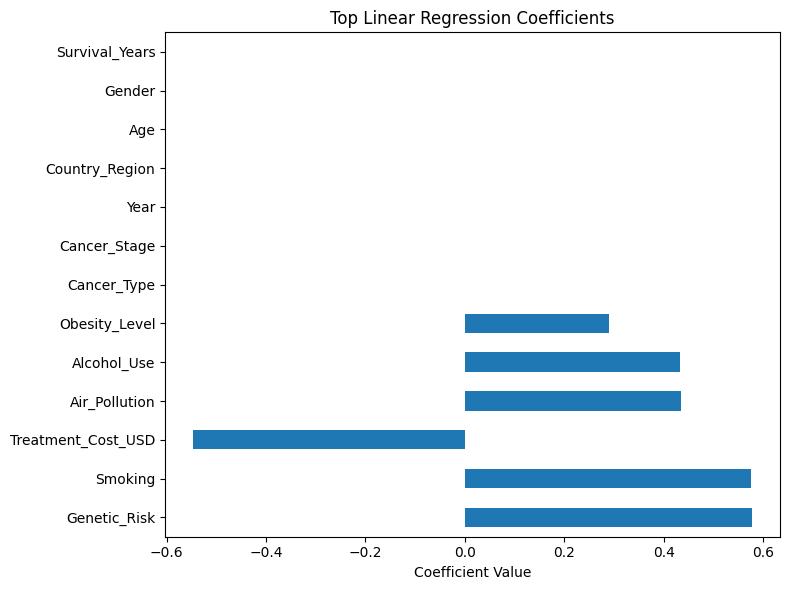

In [22]:

coef = pd.Series(lr.coef_, index=X.columns)


coef_sorted = coef.reindex(coef.abs().sort_values(ascending=False).index)


coef_sorted.plot(kind='barh', figsize=(8, 6))
plt.title("Top Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


# Interprétation des Coefficients - Régression Linéaire

Ce graphique montre les variables ayant le plus d'influence sur le modèle.

## Variables les plus influentes

- **Smoking** et **Genetic_Risk** : ont un fort impact **positif** sur la variable cible.
- **Treatment_Cost_USD** : a un impact **négatif** important.
- **Alcohol_Use** et **Air_Pollution** : effets positifs modérés.
- **Obesity_Level** : influence positive faible.

## Variables peu influentes

- **Survival_Years**, **Gender**, **Age**, **Cancer_Stage**, etc. : peu ou pas d'effet significatif dans ce modèle.




Conclusions
* Linear Regression achieved **R² ≈ 1.00**, suggesting near‑linear dependency.
* Major predictors: `Genetic_Risk`, `Smoking`, `Alcohol_Use`, `Air_Pollution` and `Treatment_Cost_USD`.


# Conclusion Générale du Projet : Prédiction de la Gravité du Cancer

Ce projet a permis de développer un modèle de prédiction de la gravité du cancer (`Target_Severity_Score`) en s’appuyant sur un large ensemble de données internationales, couvrant la période de 2015 à 2024, avec plus de 50 000 patients.

---

## Résumé des Étapes

### 1. Prétraitement
- Encodage des variables catégorielles (`Cancer_Type`, `Country_Region`, etc.)
- Normalisation des variables numériques
- Séparation en données d'entraînement et de test (80/20)

### 2. Analyse Exploratoire
- Corrélations entre les variables : mise en évidence des liens entre facteurs de risque et gravité
- Visualisations par type de cancer, stade, et région

### 3. Modélisation
Deux approches ont été testées :
- Régression Linéaire (interprétabilité)
- Arbre de Décision (capacité à capturer des non-linéarités)

---

## Résultats Clés

### Importance des variables (Arbre de Décision)
Les trois variables les plus influentes sont :
- **Smoking** (~23 %)
- **Genetic_Risk** (~22 %)
- **Treatment_Cost_USD** (~20 %)

Les variables comme `Gender`, `Age`, `Country_Region` ou `Year` ont une importance négligeable (< 1 %), ce qui indique que la gravité du cancer est peu liée aux données démographiques globales.

### Coefficients (Régression Linéaire)
- **Smoking**, **Genetic_Risk**, et **Alcohol_Use** ont les plus **grands coefficients positifs**, ce qui signifie qu’ils augmentent fortement le score de gravité.
- **Treatment_Cost_USD** possède un **coefficient négatif important**, suggérant que les patients avec des traitements coûteux ont souvent un score de gravité élevé mais inversement modéré par des soins intensifs.

---

## Interprétation Générale

Les facteurs comportementaux et biologiques sont les principaux déterminants de la gravité. Le tabagisme, l’hérédité génétique, la pollution et la consommation d’alcool sont des variables à fort pouvoir prédictif. À l'inverse, les variables administratives (année, pays) ou sociodémographiques n'ont qu’un impact marginal.

---

## Recommandations

- Mener des campagnes ciblées sur la **réduction du tabac et de l’alcool**.
- Intégrer ces modèles dans des systèmes de triage automatisés pour identifier rapidement les cas à haut risque.
- Explorer des modèles plus complexes (Random Forest, XGBoost) pour améliorer la précision.

---

## Limites et Perspectives

- Le modèle ne prend pas en compte des données cliniques détaillées (histopathologie, biologie moléculaire).
- Les relations temporelles et évolutives ne sont pas exploitées.
- Une analyse par sous-populations (par région ou type de cancer) pourrait révéler des dynamiques locales spécifiques.

---

En somme, le modèle propose une approche fiable et explicable de la prédiction de la gravité du cancer, avec un fort potentiel d’appui à la décision médicale et à la prévention ciblée après une comparaison analytique entre les modeles pour avoir le meilleur résultat.
